# VKITTI2Loader — подключение модуля

⚠️ Важно:
- Блок ниже для Nargiz использует данные из Google Drive
- Блок ниже для меня использует локально распакованный VKITTI2 в Colab (`/content/vkitti2`) и скачивает tar из Google Drive
- Общий модуль

Пути отличаются в зависимости от аккаунта.


### Для аккаунта  Nargiz

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, tarfile

VKITTI_DRIVE = '/content/drive/MyDrive/3dcv-project/data/vkitti2'

VKITTI_LOCAL = '/content/vkitti2'

os.makedirs(VKITTI_LOCAL, exist_ok=True)

# Распаковка в локальное хранилище Colab (быстрее, чем работать с Drive напрямую)

for archive in ['vkitti_2.0.3_rgb.tar', 'vkitti_2.0.3_depth.tar']:

    archive_path = f'{VKITTI_DRIVE}/{archive}'

    if os.path.exists(archive_path):

        print(f'📦 Распаковываю {archive}...')

        with tarfile.open(archive_path, 'r') as tar:

            tar.extractall(VKITTI_LOCAL)

        print(f'   ✅ Готово')

    else:

        print(f'   ❌ Не найден: {archive}')


Mounted at /content/drive
📦 Распаковываю vkitti_2.0.3_rgb.tar...


/tmp/ipykernel_2627/3638174629.py:24: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(VKITTI_LOCAL)


   ✅ Готово
📦 Распаковываю vkitti_2.0.3_depth.tar...
   ✅ Готово


In [4]:
SAVE_DIR = '/content/drive/MyDrive/3dcv-project/data/vkitti2_unpacked'

os.makedirs(SAVE_DIR, exist_ok=True)

print("✅ Папка создана:", SAVE_DIR)

✅ Папка создана: /content/drive/MyDrive/3dcv-project/data/vkitti2_unpacked


In [5]:
!cp -r /content/vkitti2/* /content/drive/MyDrive/3dcv-project/data/vkitti2_unpacked/


### Для меня

In [ ]:
!pip install -q gdown

In [ ]:
!gdown 1kkK-qZO-5hwyybCFuaEvANlRXiv-5xxj

Downloading...
From (original): https://drive.google.com/uc?id=1kkK-qZO-5hwyybCFuaEvANlRXiv-5xxj
From (redirected): https://drive.google.com/uc?id=1kkK-qZO-5hwyybCFuaEvANlRXiv-5xxj&confirm=t&uuid=7aee0e7f-523c-46a3-91c0-95f2df24bb9b
To: /content/vkitti_2.0.3_depth.tar
100% 8.15G/8.15G [01:40<00:00, 81.3MB/s]


In [ ]:
!gdown 1Ib0Kk8xFoiexv6_9DRnSI58sTQHIDjjS

Downloading...
From (original): https://drive.google.com/uc?id=1Ib0Kk8xFoiexv6_9DRnSI58sTQHIDjjS
From (redirected): https://drive.google.com/uc?id=1Ib0Kk8xFoiexv6_9DRnSI58sTQHIDjjS&confirm=t&uuid=432401fb-d3f2-42ed-a921-f3e6e44e53e7
To: /content/vkitti_2.0.3_rgb.tar
100% 7.53G/7.53G [01:42<00:00, 73.2MB/s]


In [ ]:
!ls

sample_data  vkitti_2.0.3_depth.tar  vkitti_2.0.3_rgb.tar


In [ ]:
import os, tarfile


VKITTI_LOCAL = '/content/vkitti2'

os.makedirs(VKITTI_LOCAL, exist_ok=True)


for archive in ['vkitti_2.0.3_rgb.tar', 'vkitti_2.0.3_depth.tar']:

    archive_path = f'/content/{archive}'

    if os.path.exists(archive_path):


        print(f'📦 Распаковываю {archive}...')

        with tarfile.open(archive_path, 'r') as tar:

            tar.extractall(VKITTI_LOCAL)

        print(f'   ✅ Готово')

    else:

        print(f'   ❌ Не найден: {archive}')

📦 Распаковываю vkitti_2.0.3_rgb.tar...


/tmp/ipykernel_28418/307649277.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(VKITTI_LOCAL)


   ✅ Готово
📦 Распаковываю vkitti_2.0.3_depth.tar...
   ✅ Готово


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



### Общий модуль

In [ ]:
import importlib.util

module_path = '/content/drive/MyDrive/3dcv-project/code/shared/vkitti/_loader.py'

spec = importlib.util.spec_from_file_location("vkitti_loader", module_path)

vkitti_loader = importlib.util.module_from_spec(spec)

spec.loader.exec_module(vkitti_loader)

VKITTI2Loader = vkitti_loader.VKITTI2Loader

print("✅ Модуль подключён")

✅ Модуль подключён


In [ ]:
import matplotlib.pyplot as plt

loader = VKITTI2Loader('/content/vkitti2')

frames = loader.list_frames('Scene01', 'clone')

print(f'Найдено {len(frames)} кадров в Scene01/clone')

Найдено 447 кадров в Scene01/clone


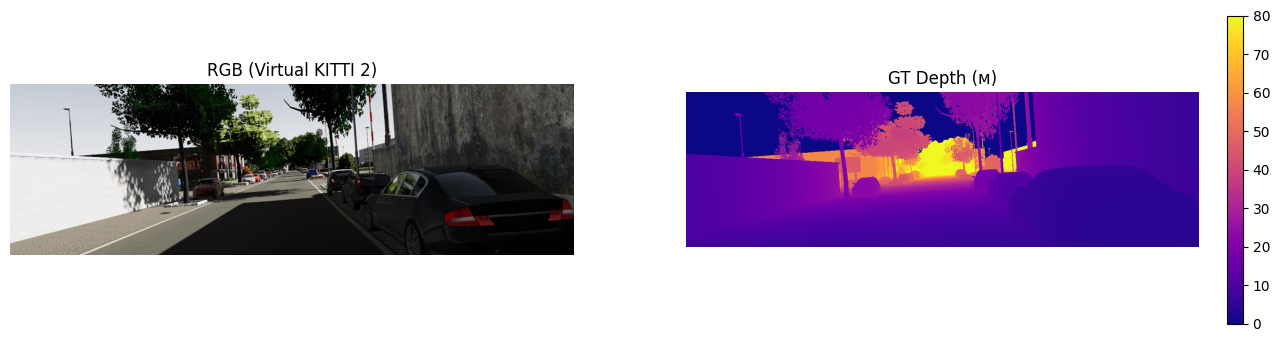

In [ ]:
rgb = loader.load_rgb('Scene01', 'clone', frames[0])

depth = loader.load_depth('Scene01', 'clone', frames[0])

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].imshow(rgb)

axes[0].set_title('RGB (Virtual KITTI 2)')

axes[0].axis('off')

im = axes[1].imshow(depth, cmap='plasma', vmin=0, vmax=80)

axes[1].set_title('GT Depth (м)')

axes[1].axis('off')

plt.colorbar(im, ax=axes[1], fraction=0.04)

plt.savefig('/content/drive/MyDrive/3dcv-project/results/track_b/B1_vkitti/sample.png',

            dpi=150, bbox_inches='tight')

plt.show()

Найдено 447 кадров в Scene01/clone
Найдено 447 кадров в Scene01/fog
Найдено 447 кадров в Scene01/morning
Найдено 447 кадров в Scene01/overcast
Найдено 447 кадров в Scene01/rain
Найдено 447 кадров в Scene01/sunset


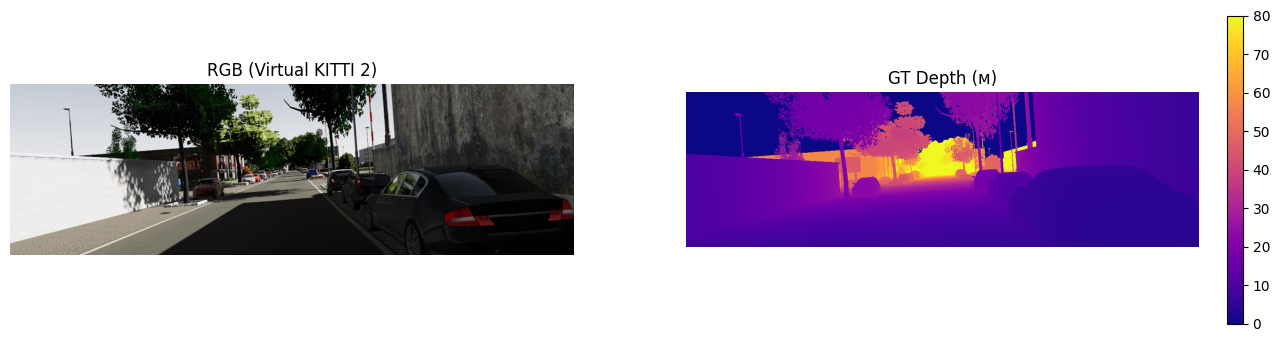

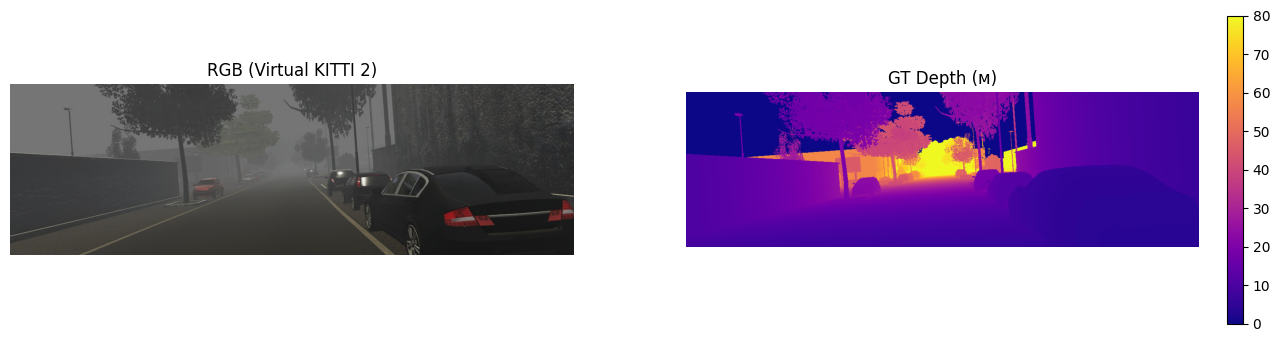

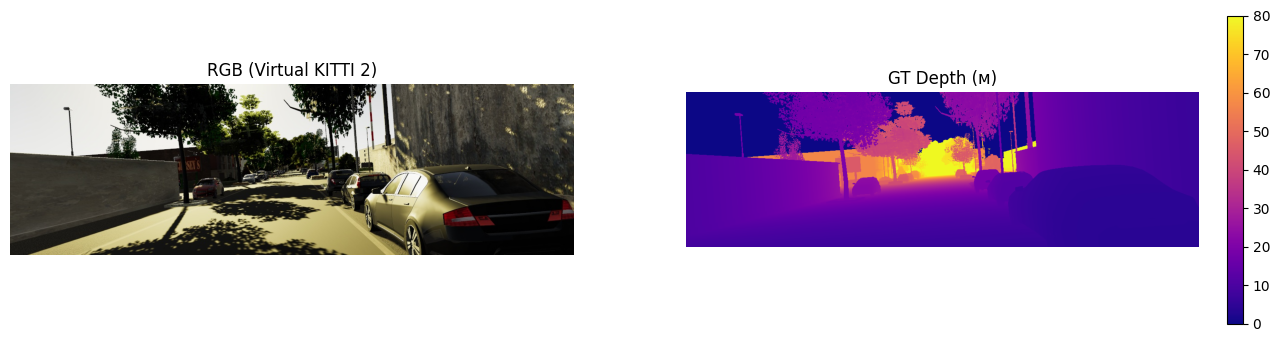

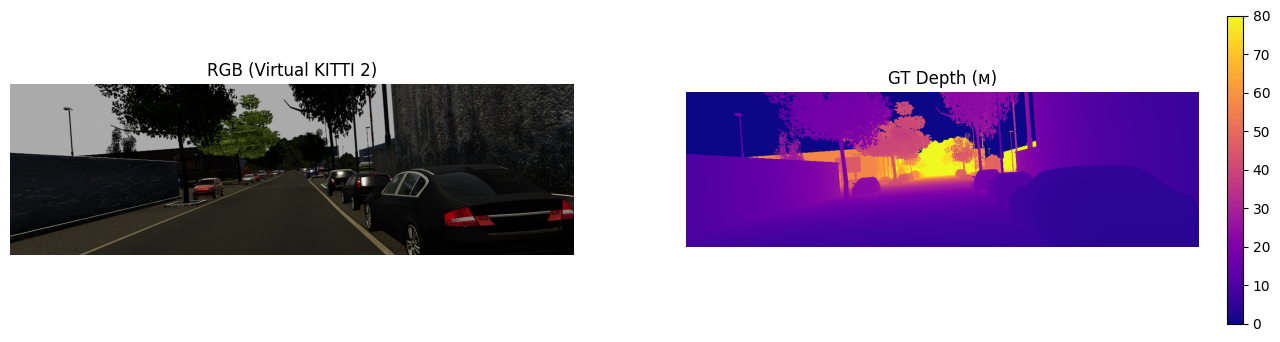

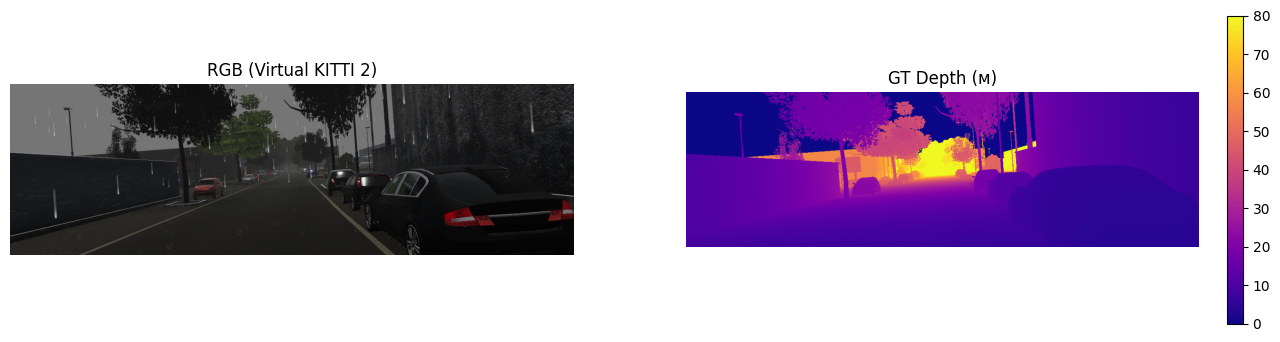

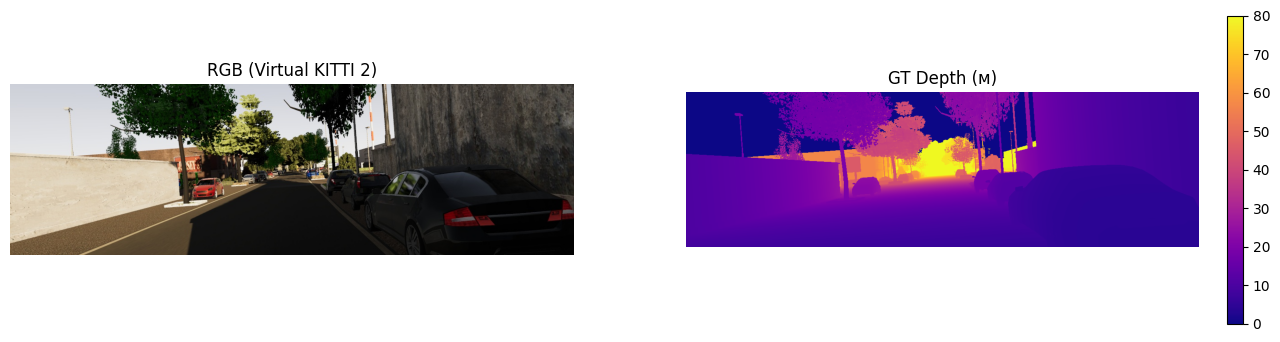

In [ ]:
variations = ['clone','fog', 'morning', 'overcast', 'rain', 'sunset']

for i, variation in enumerate(variations):
  frames = loader.list_frames('Scene01', variation)
  print(f'Найдено {len(frames)} кадров в Scene01/{variation}')

  rgb = loader.load_rgb('Scene01', variation, frames[0])

  depth = loader.load_depth('Scene01', variation, frames[0])

  fig, axes = plt.subplots(1, 2, figsize=(16, 4))

  axes[0].imshow(rgb)

  axes[0].set_title('RGB (Virtual KITTI 2)')

  axes[0].axis('off')

  im = axes[1].imshow(depth, cmap='plasma', vmin=0, vmax=80)

  axes[1].set_title('GT Depth (м)')

  axes[1].axis('off')

  plt.colorbar(im, ax=axes[1], fraction=0.04)

  plt.savefig(os.path.join('/content/drive/MyDrive/3dcv-project/results/track_b/B1_vkitti', f'{variation}_sample.png'),

            dpi=150, bbox_inches='tight')

plt.show()


